In [2]:
# Email Spam Detection using Machine Learning

#This project detects whether an email is spam or not spam using Machine Learning techniques.

In [ ]:
# Importing Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Importing Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

In [18]:
# Uploading Dataset

from google.colab import files
uploaded = files.upload()

Saving spam.csv to spam (1).csv


In [20]:
# Reading Dataset
df = pd.read_csv("/content/spam.csv", encoding='latin1')

In [25]:
# Displaying Dataset Information

print(df.head())
print(df.shape)
print(df.info())
print(df.isnull().sum())

     v1  ... Unnamed: 4
0   ham  ...        NaN
1   ham  ...        NaN
2  spam  ...        NaN
3   ham  ...        NaN
4   ham  ...        NaN

[5 rows x 5 columns]
(5572, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB
None
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64


In [27]:
# Displaying Column Names

print(df.columns)

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [28]:
# Removing Unnecessary Columns

df = df[['v1', 'v2']]

In [30]:
# Renaming Columns

df.columns = ['Category', 'Message']

In [31]:
# Displaying Clean Dataset

print(df.head())

  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...


In [32]:
# Converting Labels into Numerical Values

df['Category'] = df['Category'].map({
    'ham':0,
    'spam':1
})

In [33]:
# Converting Messages into Lowercase

df['Message'] = df['Message'].str.lower()

In [34]:
print(df.head())

   Category                                            Message
0         0  go until jurong point, crazy.. available only ...
1         0                      ok lar... joking wif u oni...
2         1  free entry in 2 a wkly comp to win fa cup fina...
3         0  u dun say so early hor... u c already then say...
4         0  nah i don't think he goes to usf, he lives aro...


In [35]:
# Checking Missing Values

print(df.isnull().sum())

Category    0
Message     0
dtype: int64


In [36]:
# Checking Duplicate Values

print(df.duplicated().sum())

404


In [37]:
# Removing Duplicate Values

df = df.drop_duplicates()

In [38]:
# Displaying Dataset Shape

print(df.shape)

(5168, 2)


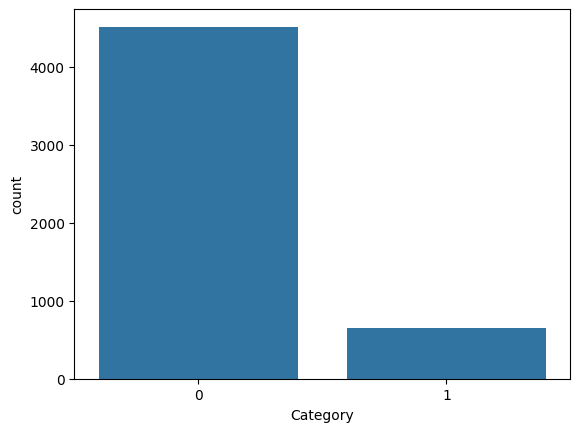

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
# Visualizing Spam vs Non-Spam Emails

sns.countplot(x='Category', data=df)
plt.show()

In [42]:
#The graph shows the sns.distribution of spam and non-spam emails in the dataset.

In [43]:
# Converting Text Data into Numerical Features

from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()

X = cv.fit_transform(df['Message'])

In [44]:
# Defining Target Variable

y = df['Category']

In [45]:
# Splitting Dataset into Training and Testing Data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [46]:
# Training Spam Detection Model

from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [47]:
# Predicting Email Categories

y_pred = model.predict(X_test)

In [48]:
# Calculating Model Accuracy

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(accuracy)

0.9748549323017408


In [49]:
#The Multinomial Naive Bayes model achieved 97.48% accuracy in classifying spam and non-spam emails.

In [50]:
# Testing Custom Email Message

sample = ["Congratulations! You won a free lottery ticket"]

sample_data = cv.transform(sample)

prediction = model.predict(sample_data)

if prediction[0] == 1:
    print("Spam Mail")
else:
    print("Not Spam Mail")

Spam Mail


In [51]:
# Testing Non-Spam Email

sample = ["Hi Sandhya, let's meet tomorrow for the project discussion."]

sample_data = cv.transform(sample)

prediction = model.predict(sample_data)

if prediction[0] == 1:
    print("Spam Mail")
else:
    print("Not Spam Mail")

Not Spam Mail


In [54]:
#The model successfully predicts whether a custom email message is spam or not spam.

In [56]:
# Conclusion

#The Email Spam Detection system was successfully developed using Machine Learning techniques.

#The model effectively classified spam and non-spam emails with 97.48% accuracy using the Multinomial Naive Bayes algorithm.